# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [1]:
from __future__ import annotations
from typing_extensions import OrderedDict

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.

In [2]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        if bias:
            self.bias = nn.Parameter(torch.zeros((out_features,)))
        else:
            self.bias = None
        self.weights = nn.Parameter(nn.init.xavier_uniform_(torch.zeros((out_features, in_features))))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        if self.bias is not None:
            out = x @ self.weights.T + self.bias
        else:
            out = x @ self.weights.T
        return out

in_features = 5
out_features = 3
linear_layer = Linear(in_features=in_features, out_features=out_features)

# Create a test input tensor of the correct shape
input_tensor = torch.randn(10, in_features)  # 10 samples, 5 features each

# Perform a forward pass
output_tensor = linear_layer(input_tensor)
print(output_tensor)

tensor([[-0.6519, -0.0282,  0.2035],
        [-0.5942,  0.3783,  0.0572],
        [ 0.4149,  0.2497, -0.1770],
        [ 2.1319,  1.3907, -0.5800],
        [ 1.0907, -0.4586, -0.0679],
        [-0.0890, -0.1206,  0.0836],
        [-0.9030,  3.1617,  0.1443],
        [ 1.2787, -0.2544, -0.1111],
        [-0.6478, -0.9041,  0.4180],
        [-2.3658,  0.6356,  0.6064]], grad_fn=<AddBackward0>)


In [3]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        w = torch.zeros((num_embeddings, embedding_dim))
        self.weights = nn.Parameter(nn.init.normal_(w))

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weights[idx, :]

num_embeddings = 10
embedding_dim = 5
embedding_layer = Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)

idx = torch.tensor([0, 2, 4])
embedding_layer(idx)

tensor([[ 1.4896, -0.0755,  0.3634,  2.0843, -1.2419],
        [-0.2433, -0.4954, -0.5930,  1.8947, -0.4136],
        [-1.2530, -0.1725,  0.6800,  1.1134, -1.2272]],
       grad_fn=<IndexBackward0>)

In [4]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if self.training:
            ps = torch.empty(x.shape)
            ps.fill_(self.p)
            dropped_channels = x * torch.bernoulli(ps)
            return dropped_channels / (1 - self.p)
        else:
            return x

dropout_layer = Dropout(p=0.5)
x = torch.ones(3, 3)
dropout_layer.train()
dropout_layer(x)

tensor([[0., 0., 0.],
        [2., 2., 0.],
        [0., 2., 2.]])

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.

In [5]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        self.weights = nn.Parameter(torch.ones((normalized_shape,)))
        self.bias = nn.Parameter(torch.zeros((normalized_shape,)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = torch.mean(x, dim=-1, keepdim=True)
        var = torch.var(x, dim=-1, keepdim=True)
        y = (x - mean) / torch.sqrt(var + self.eps)
        return y * self.weights + self.bias

layernorm = LayerNorm(normalized_shape=3)
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
layernorm(x)

tensor([[-1.0000,  0.0000,  1.0000],
        [-1.0000,  0.0000,  1.0000]], grad_fn=<AddBackward0>)

In [6]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weights = nn.Parameter(torch.ones((normalized_shape,)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        mean = torch.mean(torch.square(x), dim=-1, keepdim=True)
        y = x / torch.sqrt(mean + self.eps)
        return y * self.weights

rms_norm = RMSNorm(normalized_shape=3)
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
rms_norm(x)

tensor([[0.4629, 0.9258, 1.3887],
        [0.7895, 0.9869, 1.1843]], grad_fn=<MulBackward0>)

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
        ]
        if use_layernorm:
            layers.append(nn.LayerNorm(hidden_dim))
        for _ in range(depth-2):
            layers += [
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
            ]
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

in_dim = 8
hidden_dim = 16
out_dim = 4
depth = 3
batch_size = 5
x = torch.randn(batch_size, in_dim)
model = MLP(in_dim, hidden_dim, out_dim, depth)
model(x)

tensor([[ 0.1302, -0.1897,  0.2023,  0.2361],
        [ 0.1660, -0.2119,  0.1655,  0.1448],
        [ 0.0414, -0.1958,  0.2621,  0.2541],
        [ 0.1595, -0.2022,  0.1172,  0.2790],
        [ 0.1569, -0.1890,  0.1237,  0.2534]], grad_fn=<AddmmBackward0>)

In [8]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.model = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

batch_size = 8
d_model = 16
x = torch.randn(batch_size, d_model)
ff = FeedForward(d_model)
ff(x)

tensor([[-0.0011, -0.0084,  0.0282, -0.2329,  0.2240,  0.0345,  0.0949, -0.0270,
          0.1700,  0.2047,  0.2781, -0.0799,  0.0864,  0.0740,  0.1078,  0.1356],
        [ 0.1089,  0.0136, -0.1650, -0.2200,  0.3087, -0.0258, -0.0027, -0.1669,
          0.1911,  0.1237,  0.2791, -0.1549,  0.0011,  0.0125, -0.2614, -0.0420],
        [-0.0112,  0.1006, -0.0916, -0.0910,  0.3516,  0.4141, -0.1390,  0.2738,
          0.1047,  0.2065,  0.0737, -0.3066, -0.1760, -0.1152, -0.4680,  0.0265],
        [ 0.1709, -0.2372, -0.0482, -0.0589,  0.0594, -0.0736, -0.2177,  0.0445,
         -0.0856, -0.0628, -0.0925, -0.0944,  0.2087,  0.1704,  0.1072,  0.0549],
        [-0.0695, -0.2136, -0.1915, -0.4365,  0.3010,  0.0324, -0.2331, -0.1465,
         -0.0110, -0.0480, -0.1156,  0.0953, -0.0992, -0.0570,  0.0064,  0.0675],
        [ 0.0125,  0.1709, -0.0303, -0.0986, -0.1452, -0.0295, -0.1991, -0.0821,
         -0.2304,  0.0558,  0.0798, -0.3691,  0.1485, -0.1190, -0.1073,  0.4748],
        [-0.1936,  0.1

In [9]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

class CustomModule(nn.Module):
    def forward(self, x, scale=1.0, bias=None):
        out = x * scale
        if bias is not None:
            out = out + bias
        return out

batch_size, dim = 3, 5
x = torch.randn(batch_size, dim)
bias = torch.ones(batch_size, dim)
residual_block = Residual(CustomModule())
residual_block(x, scale=2.0, bias=bias)

tensor([[ 2.4203,  3.8000, -1.4262,  1.8346, -1.8969],
        [-0.5678,  1.2130,  1.5429,  1.2690, -4.6941],
        [ 3.3077,  0.3500, -0.2910,  2.7630,  1.3421]])

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy.
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

data_loader_train = DataLoader(train_ds, batch_size=32)
data_loader_test = DataLoader(test_ds, batch_size=32)

In [12]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    B = logits.size(0)
    return -torch.nn.functional.log_softmax(logits, dim=-1)[torch.arange(B), targets].mean()

B, C = 4, 5
torch.manual_seed(0)
logits = torch.randn(B, C)
targets = torch.randint(0, C, (B,))
loss_custom = cross_entropy_from_logits(logits, targets)
loss_torch = nn.CrossEntropyLoss()(logits, targets)
loss_custom, loss_torch

(tensor(1.8281), tensor(1.8281))

In [13]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.model = nn.Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.model(x)

batch_size = 5
d_in = 10
num_classes = 4
x = torch.randn(batch_size, d_in)
head = ClassificationHead(d_in, num_classes)
head(x)

tensor([[ 0.5435, -0.4371, -0.1210, -0.4081],
        [ 0.8769,  0.0604,  0.1504, -0.1604],
        [-0.5334,  0.2181, -0.5529, -0.2801],
        [-0.2531,  0.2670, -1.5583,  1.3060],
        [ 0.1591, -0.0931, -0.6437, -0.2352]], grad_fn=<AddmmBackward0>)

In [14]:
def accuracy(loader: DataLoader, model: nn.Module):
    model.eval()
    correct_guesses = 0
    total_samples = 0
    for x_batch, y_batch in loader:
        x_batch = x_batch.view(x_batch.size(0), -1)
        logits = model(x_batch)
        _, predicted = torch.max(logits, dim=-1)
        correct_guesses += (predicted == y_batch).sum().item()
        total_samples += y_batch.size(0)
    return correct_guesses / total_samples

In [15]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    g = torch.Generator(device)
    g.manual_seed(seed)
    model = model.to(device)
    model.train()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []
    for step in range(epochs):
        for xb, yb in train_data_loader:
            xb, yb = xb.to(device), yb.to(device)
            xb= xb.view(xb.size(0), -1) # flatten data
            logits = model(xb)
            loss = cross_entropy_from_logits(logits, yb)
            losses.append(loss.detach())
            optim.zero_grad()
            loss.backward()
            optim.step()
        print(f"Accuracy after epoch {step+1}: {accuracy(test_data_loader, model)}")
    return losses

model = ClassificationHead(784, 10)
losses = train_classifier(model, data_loader_train, data_loader_test, lr=0.001, epochs=1, seed=17)

Accuracy after epoch 1: 0.9146


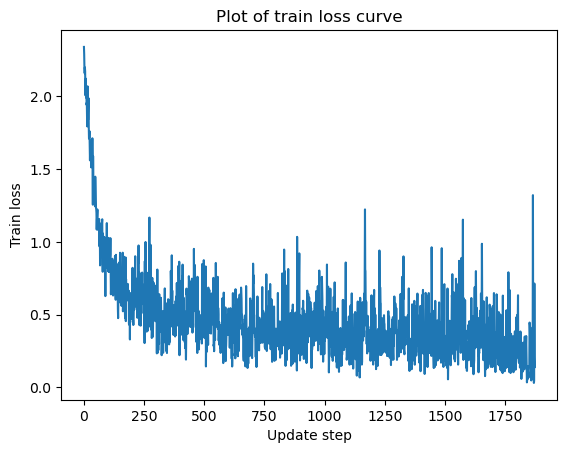

In [16]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('Plot of train loss curve')
plt.xlabel('Update step')
plt.ylabel('Train loss')
plt.show()